# Understanding Legal Reasoning in US Supreme Court Opinions with Machine Learning

## Research Background

### Question

**How much does the US Supreme Court declare law versus apply law in its opinions?**

### Background

Legal scholars Henry Hart and Albert Sacks have famously described three different things that every case requires a judge to do: (1) declare law, (2) find facts, and then (3) apply the law declared to the facts found (Proctor 2024, pp. 979–80). The judicial role in applying law and facts has long been contested. The distinction is incredibly important since whether the Supreme Court is declaring law or applying law can impact how the case is cited and used by lower federal courts. When the Supreme Court declares more law, the opinion can potentially be read more expansively and give lower courts more discretion. When the Supreme Court opinion is more focused on applying law, then lower courts have less discretion when a new case with different facts comes up. 

It is traditionally been very challenging to distinguish between when the Supreme Court acts as a declarer of law versus an applier of law. Machine learning is helpful because it can help excavate and utilize textual clues to distinguish the law declaring from the law applying portions of opinions. Scholars can then use this classification to evaluate which Supreme Court opinions are more restrained (law applying) and which are more maximalist (law declaring). This is a big improvement over ad-hoc scholarly evaluations as to whether a particular Supreme Court opinion is a significant change in the law or more constrained to the case at hand.

In addition to these efficiency-saving and error-reducing benefits of machine learning, this article will build on a slow but growing literature on machine learning in the judiciary. Recent work has used machine learning to predictively model Supreme Court case outcomes based on the facts of the case (Lockhard, et al 2023) and study methods of statutory interpretation in state supreme courts (Peters 2024). This work adds to this literature. It provides the first text-based empirical approach to measuring judicial restraint and understanding how this measure has changed over time.

In what follows, I will focus on the first task in answering this research question: dividing Supreme Court majority opinion text into either legal reasoning or non-legal reasoning. This sets the stage for the second step which is to classify each legal reasoning portion of opinions as either law declaring or law applying (which I will pursue as a future research project).

## Section 1: Data Collection

I started my analysis by gathering data. I used the [CourtListener](https://www.courtlistener.com/opinion/) API which contains texts of opinions from all US courts including the Supreme Court of the United States (SCOTUS). To avoid storage and memory issues on my computer, I decided to focus on majority opinions from SCOTUS since John Roberts became Chief Justice in September 2005. This includes both majority and unsigned per curiam opinions that represent the law as decided by the court. 

In [1]:
# load package for API requests
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [20]:
import requests
import time

API_KEY = "" # API key removed for privacy

headers = {"Authorization": f"Token {API_KEY}"} 

# CourtListener API query parameters focus on combined opinions from the Supreme Court since John Roberts became Chief Justice
url = "https://www.courtlistener.com/api/rest/v4/opinions/" 
params = { 
    "cluster__docket__court": "scotus", 
    "cluster__date_filed__gte": "2005-09-29", 
    "type": "010combined", 
    "page_size": 100
}

opinions = []
retries = 3 # retry up to 3 times for server errors in case of time out error

# Loop to send requests using the parameters above. AI assistance was used to write and refine this code.
while url:
    success = False
    attempt = 0
    while not success and attempt < retries:
        attempt += 1
        try:
            response = requests.get(url, headers=headers, params=params, timeout=10)
            if response.status_code == 200:
                data = response.json()
                opinions.extend(data["results"])
                url = data["next"] 
                params = None # only use params on the first request 
                success = True 
                print(f"Fetched {len(opinions)} opinions so far...") 
                time.sleep(0.3) 
            else: 
                print(f"HTTP {response.status_code} error, retrying...")
                time.sleep(2) 
        except requests.exceptions.RequestException as e: 
            print("Request failed:", e)
            time.sleep(2) 

print("Total Roberts-era majority SCOTUS opinions:", len(opinions))


Request failed: HTTPSConnectionPool(host='www.courtlistener.com', port=443): Read timed out. (read timeout=10)
Request failed: HTTPSConnectionPool(host='www.courtlistener.com', port=443): Read timed out. (read timeout=10)
Request failed: HTTPSConnectionPool(host='www.courtlistener.com', port=443): Read timed out. (read timeout=10)
Fetched 20 opinions so far...
Fetched 40 opinions so far...
Fetched 60 opinions so far...
Fetched 80 opinions so far...
Fetched 100 opinions so far...
Fetched 120 opinions so far...
Fetched 140 opinions so far...
Fetched 160 opinions so far...
Fetched 180 opinions so far...
Fetched 200 opinions so far...
Fetched 220 opinions so far...
Fetched 240 opinions so far...
Fetched 260 opinions so far...
Fetched 280 opinions so far...
Fetched 300 opinions so far...
Fetched 320 opinions so far...
Fetched 340 opinions so far...
Fetched 360 opinions so far...
Fetched 380 opinions so far...
Fetched 400 opinions so far...
Fetched 420 opinions so far...
Fetched 440 opinions

After identifying the 3026 SCOTUS opinions, I focused on getting the opinion text.

In [21]:
import requests
import time

API_KEY = "" # private API key
headers = {"Authorization": f"Token {API_KEY}"}

# List of opinion resource URIs from API responses above
opinions_resource_uris = [op["resource_uri"] for op in opinions]

opinions_texts = []

# Loop for obtaining opinion texts through API request. This code used AI assistance to write and refine.
for i, uri in enumerate(opinions_resource_uris, start=1):
    success = False
    retries = 0
    while not success and retries < 5:
        try:
            response = requests.get(uri, headers=headers, timeout=10)
            if response.status_code == 200:
                data = response.json()
                # Some opinions may have plain_text or html. Use plain_text if available
                text = data.get("plain_text") or data.get("html") or ""
                opinions_texts.append({"id": data["id"], "text": text})
                success = True
            else:
                print(f"Non-200 status for {uri}: {response.status_code}")
                retries += 1
                time.sleep(1)
        except requests.exceptions.RequestException as e:
            print(f"Request failed for {uri}: {e}")
            retries += 1
            time.sleep(1)
    
    if i % 50 == 0:
        print(f"Fetched {i}/{len(opinions_resource_uris)} opinions")
    
    time.sleep(0.2)  # be gentle to the API

print(f"Finished fetching {len(opinions_texts)} opinions")


Fetched 50/3026 opinions
Fetched 100/3026 opinions
Fetched 150/3026 opinions
Fetched 200/3026 opinions
Fetched 250/3026 opinions
Fetched 300/3026 opinions
Fetched 350/3026 opinions
Fetched 400/3026 opinions
Fetched 450/3026 opinions
Fetched 500/3026 opinions
Non-200 status for https://www.courtlistener.com/api/rest/v4/opinions/9387021/: 502
Fetched 550/3026 opinions
Fetched 600/3026 opinions
Fetched 650/3026 opinions
Fetched 700/3026 opinions
Fetched 750/3026 opinions
Fetched 800/3026 opinions
Fetched 850/3026 opinions
Fetched 900/3026 opinions
Fetched 950/3026 opinions
Fetched 1000/3026 opinions
Fetched 1050/3026 opinions
Fetched 1100/3026 opinions
Fetched 1150/3026 opinions
Fetched 1200/3026 opinions
Fetched 1250/3026 opinions
Fetched 1300/3026 opinions
Fetched 1350/3026 opinions
Fetched 1400/3026 opinions
Fetched 1450/3026 opinions
Fetched 1500/3026 opinions
Fetched 1550/3026 opinions
Fetched 1600/3026 opinions
Fetched 1650/3026 opinions
Fetched 1700/3026 opinions
Fetched 1750/3026 

In [24]:
# this provides an example of one sample from the resulting data
print(opinions[0])

{'resource_uri': 'https://www.courtlistener.com/api/rest/v4/opinions/1722/', 'id': 1722, 'absolute_url': '/opinion/1722/shady-grove-orthopedic-associates-p-a-v-allstate-insurance/', 'cluster_id': 1722, 'cluster': 'https://www.courtlistener.com/api/rest/v4/clusters/1722/', 'author_id': None, 'author': None, 'joined_by': [], 'date_created': '2010-04-15T12:40:06-07:00', 'date_modified': '2025-07-17T18:02:47.984319-07:00', 'author_str': '', 'per_curiam': False, 'joined_by_str': '', 'type': '010combined', 'sha1': '840c87c5d95464bb384f53ba353602d889712a2d', 'page_count': 72, 'download_url': 'http://www.supremecourt.gov/opinions/09pdf/08-1008.pdf', 'local_path': 'pdf/2010/03/31/Shady_Grove_Orthopedic_Associates_P._A._v._Allstate_Ins._Co..pdf', 'plain_text': '(Slip Opinion)              OCTOBER TERM, 2009                                       1\n\n                                       Syllabus\n\n         NOTE: Where it is feasible, a syllabus (headnote) will be released, as is\n       being 

Now that we have opinion texts, we can put all the opinions into a dataframe.

In [26]:
dataset = []

for op in opinions:
    dataset.append({
        "case_id": op["cluster_id"],
        "opinion_id": op["id"],
        "date_created": op.get("date_created"),
        "opinion_text": op.get("plain_text"),
        "is_majority": (op["type"] == "010combined")
    })

print(f"Created dataset with {len(dataset)} observations")


Created dataset with 3026 observations


In [28]:
import pandas as pd

df = pd.DataFrame(dataset)

# Example: see first 5 rows
print(df.head())

    case_id  opinion_id                      date_created  \
0  10779476    11246089  2026-01-26T08:01:31.466383-08:00   
1  10776881    11243468  2026-01-20T10:03:17.097360-08:00   
2  10776880    11243467  2026-01-20T10:03:15.525902-08:00   
3  10776879    11243466  2026-01-20T10:03:14.036111-08:00   
4  10776878    11243465  2026-01-20T10:03:12.471348-08:00   

                                        opinion_text  is_majority  
0                    Cite as: 607 U. S. ____ (202...         True  
1                     PRELIMINARY PRINT\n\n      ...         True  
2                     PRELIMINARY PRINT\n\n      ...         True  
3                     PRELIMINARY PRINT\n\n      ...         True  
4                     PRELIMINARY PRINT\n\n      ...         True  


As shown above, there are five features in the data. The first three all come from the CourtListener API metadata and the last two have been created above. `case_id`, `opinion_id`, and `date_created` are all numeric; `opinion_text` is text; and `is_majority` is a categorical boolean.

## Section 2 - Data Cleaning

The first step was to check for duplicates. I realized that some cases show up in court listener under different `case_id`s so I decided to look for true duplicates based on opinion text. I am not sure this is perfect but it at least gets rid of the true duplicates.

In [33]:
# check for duplicates based on opinion_text
df_dup = df.duplicated(subset=['opinion_text'])
df_dup.sum()

np.int64(591)

In [35]:
# remove duplicates
print(len(df))
df = df.drop_duplicates(subset=['opinion_text'])
print(len(df))

3026
2435


In [36]:
# save dataframe
df.to_parquet("scotus_majority_opinions.parquet", index=False)

In [140]:
# reload data
import pandas as pd
df = pd.read_parquet("scotus_majority_opinions.parquet")

In [141]:
sample_df = df.sample(n=10, random_state=42)
sample_df
print(len(df))

2435


Next, even though I retrieved combined opinions through my API query, I still need to narrow these to majority opinions. A reliable pattern has been to use "It is so ordered." or "Affirmed." or "Reversed." to indicate the end of a majority opinion.

In [142]:
import re

pattern = re.compile(
    r"(It is so ordered\.|^\s*(Affirmed|Reversed)\.\s*$)",
    flags=re.IGNORECASE | re.MULTILINE
)
# AI assisted in updating and fixing this function
def keep_majority_opinion(text):
    match = pattern.search(text)
    if match:
        return text[:match.end()]   # truncate after match
    return None  # drop rows with no majority-ending pattern

df["majority_opinion"] = df["opinion_text"].apply(keep_majority_opinion)

# Remove non-matching rows
df = df[df["majority_opinion"].notna()]


This brings the dataset down to 1856 cases.

In [143]:
print(len(df))

1856


The next step in cleaning was to try and ignore all the front matter. I had AI try to help me clean up some of this but it was ultimately not particularly successful. Much of the front matter remained in the hand-labeled sample.

In [144]:
import re
import pandas as pd

# ----------------------------
# 1. Remove Front Matter
# ----------------------------
def remove_front_matter(text):
    pattern = r"(Per Curiam\.|JUSTICE .*? delivered the opinion of the Court\.|Chief Justice .*? delivered the opinion of the Court\.|Justice .*? delivered the opinion of the Court\.)"
    match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
    if match:
        return text[match.start():]
    return text


# ----------------------------
# 2. Full Cleaning Function
# ----------------------------
def clean_opinion(text):
    text = remove_front_matter(text)
    return text


# ----------------------------
# 3. Apply Cleaning 
# ----------------------------
df["clean_majority"] = df["majority_opinion"].apply(clean_opinion)


The final step in data cleaning was to identify paragraph breaks so that each row in the dataframe could be a paragraph and analyzed as such. This prove to be the most challenging part. The below code performs fairly well at splitting into paragraphs but is far from perfect. I plan to keep refining it with AI assistance. The following functions for identifying and dividing into paragraphs are explained below.

In [145]:
"""
Supreme Court Opinion Parser
"""

import re
from typing import List


def clean_line(line: str) -> str:
    """
    Remove case names and page numbers that appear at the end of lines.
    """
    # Remove case name headers that appear at end of line (e.g., "2 KLEIN v. MARTIN")
    line = re.sub(r'\s+\d*\s*[A-Z][A-Z\s]+v\.\s+[A-Z][A-Z\s]+$', '', line)
    
    # Remove standalone page numbers at end of line
    line = re.sub(r'\s+\d+\s*$', '', line)
    
    return line


def should_skip_line(line: str) -> bool:
    """
    Determine if a line should be skipped (header/footer/citation).
    """
    # Skip citation patterns like "Cite as: 607 U. S. ____ (2026)"
    if re.match(r'Cite as:.*\d{4}\)', line):
        return True
    
    # Skip page numbers (standalone numbers)
    if re.match(r'^\d+$', line):
        return True
    
    # Skip case name headers like "2 KLEIN v. MARTIN"
    if re.match(r'^\d*\s*[A-Z][A-Z\s]+v\.\s+[A-Z][A-Z\s]+$', line):
        return True
    
    # Skip "Per Curiam" headers
    if line.strip() == "Per Curiam":
        return True
    
    # Skip section numbers (Roman numerals)
    if re.match(r'^[IVX]+$', line):
        return True
    
    # Skip standalone letters (section labels)
    if re.match(r'^[A-Z]$', line):
        return True
    
    # Skip footnote separator lines (dashes/underscores)
    if re.match(r'^[_\-—]{2,}$', line):
        return True
    
    # Skip "Page Proof Pending Publication" header
    if "Page Proof Pending Publication" in line:
        return True
    
    return False


def is_footnote(line: str) -> bool:
    """
    Check if a line is a footnote (starts with asterisk or number).
    """
    # Footnotes typically start with * or a number followed by space
    if re.match(r'^\*\s*.+', line):
        return True
    if re.match(r'^\d+\s+.+', line) and len(line) < 200:  # Short numbered lines
        return True
    return False


def ends_complete_sentence(text: str) -> bool:
    """
    Check if text ends with a complete sentence (proper punctuation).
    """
    text = text.rstrip()
    
    # Check if ends with sentence-ending punctuation
    if text.endswith(('.', '!', '?', ':', ';')):
        return True
    
    # Check if ends with a closing parenthesis after punctuation
    if text.endswith(('."', ".'", '!"', "!'", '?"', "?'", ')"', ")'")):
        return True
    
    # Check if ends with citation patterns like "App. 254a."
    if re.search(r'\b[A-Z][a-z]*\.\s*\d+[a-z]?\.$', text):
        return True
    
    return False


def parse_supreme_court_opinion(text: str) -> List[str]:
    """
    Parse a Supreme Court opinion into a list of paragraphs.
    """
    lines = text.split('\n')
    
    paragraphs = []
    current_paragraph = []
    last_line_complete = True
    
    for i, line in enumerate(lines):
        original_line = line
        
        # Clean the line (remove case names/page numbers at end)
        line = clean_line(line)
        stripped = line.strip()
        
        # Skip empty lines
        if not stripped:
            # Only save paragraph if last line was complete
            if current_paragraph and last_line_complete:
                paragraphs.append(' '.join(current_paragraph))
                current_paragraph = []
            continue
        
        # Skip header/footer patterns
        if should_skip_line(stripped):
            # Don't save paragraph for footnote separators - keep building
            continue
        
        # Check if this is a footnote - if so, add to current paragraph
        if is_footnote(stripped):
            current_paragraph.append(stripped)
            # Footnotes don't count as completing a sentence
            # Keep last_line_complete unchanged so next line continues the paragraph
            continue
        
        # Check if line is indented (starts new paragraph)
        is_indented = len(original_line) - len(original_line.lstrip()) >= 2
        
        # Start new paragraph if:
        # 1. Line is indented AND
        # 2. We have content already AND
        # 3. Previous line was a complete sentence
        if current_paragraph and is_indented and last_line_complete:
            paragraphs.append(' '.join(current_paragraph))
            current_paragraph = []
        
        # Add line to current paragraph
        current_paragraph.append(stripped)
        
        # Check if this line ends a complete sentence
        last_line_complete = ends_complete_sentence(stripped)
    
    # Don't forget the last paragraph
    if current_paragraph:
        paragraphs.append(' '.join(current_paragraph))
    
    return paragraphs


def clean_paragraph(paragraph: str) -> str:
    """
    Clean up a paragraph by normalizing spacing and formatting.
    """
    # Fix hyphenated line breaks (e.g., "re- sult" -> "result")
    # Match: word fragment, hyphen, space(s), word fragment
    paragraph = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', paragraph)
    
    # Normalize multiple spaces to single space
    paragraph = re.sub(r'\s+', ' ', paragraph)
    
    # Remove leading/trailing whitespace
    paragraph = paragraph.strip()
    
    return paragraph


# Example usage:
# paragraphs = parse_supreme_court_opinion(majority_opinion)
# for i, para in enumerate(paragraphs, 1):
#     print(f"Paragraph {i}: {clean_paragraph(para)}")

In [146]:
# Parse all opinions and store in a new column
df["paragraphs"] = df["clean_majority"].apply(parse_supreme_court_opinion)

Now each row has a list of paragraphs

In [147]:
# To see the first opinion's paragraphs:
for i, para in enumerate(df["paragraphs"].iloc[24], 1):
    print(f"Paragraph {i}: {clean_paragraph(para)}\n")

Paragraph 1: Per Curiam.

Paragraph 2: On March 10, 2025, the United States District Court for the District of Massachusetts issued what it styled as a temporary restraining order (TRO) enjoining the Government from terminating various education-related grants. The order also requires the Government to pay out past-due grant obligations and to continue paying obligations as they accrue. The District Court's conclusion rested on a fnding that respondents are likely to succeed on the merits of their claims under the Administrative Procedure Act (APA), Stat. 237. On March 26, the Government fled this application to vacate the District Court's March 10 order (as extended on March 24) and requested an immediate administrative stay. The application was presented to Justice Jackson and by her referred to the Court.

Paragraph 3: Although the Courts of Appeals generally lack appellate jurisdiction over appeals from TROs, several factors counsel in favor of construing the District Court's order

In [148]:
df.to_parquet("scotus_majority_opinions_clean.parquet", index=False)

We can now split each paragraph into its own row. AI assistance was used to help with this step.

In [149]:
def expand_to_paragraphs_simple(df, text_column='majority_opinion', keep_original=False):
    """
    Simpler version that only keeps essential paragraph information.
    
    Args:
        df: DataFrame with one row per case
        text_column: Name of the column containing the opinion text
        keep_original: Whether to keep the original full opinion text column
        
    Returns:
        New DataFrame with one row per paragraph
    """
    expanded_rows = []
    
    for idx, row in df.iterrows():
        opinion_text = row[text_column]
        paragraphs = parse_supreme_court_opinion(opinion_text)
        
        for para_num, para_text in enumerate(paragraphs, 1):
            new_row = row.to_dict()
            new_row['paragraph_number'] = para_num
            new_row['paragraph_text'] = clean_paragraph(para_text)
            new_row['total_paragraphs'] = len(paragraphs)
            expanded_rows.append(new_row)
    
    expanded_df = pd.DataFrame(expanded_rows)
    
    # Optionally remove the original full opinion text to save space
    if not keep_original and text_column in expanded_df.columns:
        expanded_df = expanded_df.drop(columns=[text_column])
    
    return expanded_df


In [150]:
# applying function from above
df_paragraphs = expand_to_paragraphs_simple(df, text_column='clean_majority', keep_original=False)

The new dataset, with each sample representing a row now has 83,040 samples.

In [151]:
print(len(df_paragraphs))

83040


In [152]:
df_paragraphs.head()

,case_id,opinion_id,date_created,opinion_text,is_majority,majority_opinion,paragraphs,paragraph_number,paragraph_text,total_paragraphs
0,10779476,11246089,2026-01-26T08:01:31.466383-08:00,Cite as: 607 U. S. ____ (202...,True,Cite as: 607 U. S. ____ (202...,"[PER CURIAM., Under the Antiterrorism and Effe...",1,PER CURIAM.,36
1,10779476,11246089,2026-01-26T08:01:31.466383-08:00,Cite as: 607 U. S. ____ (202...,True,Cite as: 607 U. S. ____ (202...,"[PER CURIAM., Under the Antiterrorism and Effe...",2,Under the Antiterrorism and Effective Death Pe...,36
2,10779476,11246089,2026-01-26T08:01:31.466383-08:00,Cite as: 607 U. S. ____ (202...,True,Cite as: 607 U. S. ____ (202...,"[PER CURIAM., Under the Antiterrorism and Effe...",3,This is such a case. Respondent Charles Brando...,36
3,10779476,11246089,2026-01-26T08:01:31.466383-08:00,Cite as: 607 U. S. ____ (202...,True,Cite as: 607 U. S. ____ (202...,"[PER CURIAM., Under the Antiterrorism and Effe...",4,"Torok, the victim of the attempted murder, had...",36
4,10779476,11246089,2026-01-26T08:01:31.466383-08:00,Cite as: 607 U. S. ____ (202...,True,Cite as: 607 U. S. ____ (202...,"[PER CURIAM., Under the Antiterrorism and Effe...",5,"A few weeks later, Martin sent Torok a text me...",36


I decided to remove some unwanted features to keep the dataframe compact. This leaves the dataframe with 6 features.

In [153]:
# Remove unwanted features
df_reduced = df_paragraphs.drop(
    columns=["opinion_text", "is_majority", "majority_opinion", "paragraphs"]
)

## Section 3 - Labeling Data

The next step was to hand label a sample of the data to generate a target variable. Overall, the goal was to identify when the Supreme Court declares law versus applies law. However, to get there, I needed to first identify the part of the opinion that involves legal reasoning (as opposed to the procedural background). This itself was a classification task that required labeling each paragraph in the dataset as either a legal or non-legal paragraph.

To start, I randomly sampled 100 unique case ids from the dataset and then created a CSV file that I could use to label the target variable `legal`. The sampled labeling dataset contained 4953 paragraphs across the 100 cases.

In [154]:
# Randomly sample 100 unique case_ids
sampled_case_ids = (
    df_reduced["case_id"]
    .drop_duplicates()
    .sample(n=100, random_state=42)
)

# Keep all rows belonging to those sampled cases
sample_df = df_reduced[df_reduced["case_id"].isin(sampled_case_ids)]

In [155]:
print(len(sample_df))

4953


In [156]:
sample_df.to_csv("samp_100_cases.csv", index=False)

For ease of dealing with duplicates later, I removed all the rows that I sampled from in the original dataframe.

In [157]:
df_reduced = df_reduced.merge(sample_df.drop_duplicates(), 
              how="left", 
              indicator=True)

df_reduced = df_reduced[df_reduced["_merge"] == "left_only"].drop(columns=["_merge"])

I used this CSV file to do manual labeling. The first task was essentially reading through each the 4,953 paragraphs from the 100 opinions and determine whether they were a paragraph dealing with legal reasoning or not. Many cases begin with a procedural history and background before actually starting the legal analysis. This cleaning step is crucial to my overall project. After labeling, I checked for balance. There were 3,139 paragraphs that involved legal reasoning compared to 1,814 paragraphs that were purely procedural and non-legal. This created a somewhat balanced distribution of labels - about 63% of paragraphs were legal and 37

In [158]:
labeled_df = pd.read_csv("samp_300_clean.csv")
labeled_df.head()

,case_id,opinion_id,date_created,paragraph_number,paragraph_text,total_paragraphs,legal,Unnamed: 7
0,10776853,11243440,2026-01-20T10:02:37.399342-08:00,1,Justice Gorsuch delivered the opinion of the C...,38,0,NaN
1,10776853,11243440,2026-01-20T10:02:37.399342-08:00,2,Tens of thousands of federal civilian employee...,38,0,NaN
2,10776853,11243440,2026-01-20T10:02:37.399342-08:00,3,Page Proof Pending Publication Nick Feliciano ...,38,0,NaN
3,10776853,11243440,2026-01-20T10:02:37.399342-08:00,4,Opinion of the Court Guard ordered him to acti...,38,0,NaN
4,10776853,11243440,2026-01-20T10:02:37.399342-08:00,5,"During much of that period, the statutory auth...",38,0,NaN


I realized after labeling that the `date_created` variable needed to be removed since the formatting changed from within the way the csv file saved in Microsoft Excel on my machine.

In [159]:
labeled_df = labeled_df.drop(columns=['date_created', 'Unnamed: 7'])
labeled_df.head()

,case_id,opinion_id,paragraph_number,paragraph_text,total_paragraphs,legal
0,10776853,11243440,1,Justice Gorsuch delivered the opinion of the C...,38,0
1,10776853,11243440,2,Tens of thousands of federal civilian employee...,38,0
2,10776853,11243440,3,Page Proof Pending Publication Nick Feliciano ...,38,0
3,10776853,11243440,4,Opinion of the Court Guard ordered him to acti...,38,0
4,10776853,11243440,5,"During much of that period, the statutory auth...",38,0


## Section 4: Training and Testing with Models

### Tree-Based Model

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
vectorizer = TfidfVectorizer()

Prepare the features and target variable

In [33]:
X_data = labeled_df.drop("legal", axis=1)
X_data = vectorizer.fit_transform(X_data["paragraph_text"])

feature_names = vectorizer.get_feature_names_out()
X_data.shape

(4953, 25356)

In [34]:
# create target
y_data = labeled_df["legal"]
y_data.shape

(4953,)

In [35]:
# split into training and testing
X_train, X_test, y_train, y_test  = train_test_split(X_data, y_data, test_size = 0.2, random_state = 42)

In [36]:
# Check the shape of training and testing feature matrix
X_train.shape, X_test.shape

((3962, 25356), (991, 25356))

In choosing to use a random forest classifier model, I was worried about potential noise from having a small sample to work with (just under 5,000 labeled samples). Given this, I thought it would be better to average over many trees. However, I ran both to get a sense of comparison. I tried a variety of hyperparameters and checked each with cross-validation for comparison across different parameter performances. To more effectively hyperparameter tune, I used GridSearchCV.

In [38]:
# fit DT classifier model
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf = dt_clf.fit(X_train, y_train)

# define hyperparameter grid
param_grid = {
    "criterion": ["entropy", "log_loss", "gini"],
    "max_depth":[None, 3, 7, 10, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 10]
}

# run gridsearch
grid_search = GridSearchCV(
    estimator = dt_clf,
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)
grid_search.fit(X_train, y_train)

# print best
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 2}


In [39]:
# fit the model with best parameters
dt_clf = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=7, min_samples_leaf=3, min_samples_split=2)
dt_clf = dt_clf.fit(X_train, y_train)

# check cross-validation score
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(dt_clf, X_train, y_train, cv=5)
cv_scores

array([0.72383354, 0.75662043, 0.72979798, 0.75757576, 0.73358586])

In [41]:
# fit random forest model
rf_clf = RandomForestClassifier(random_state=42)
rf_clf = rf_clf.fit(X_train, y_train)

# define hyperparameter grid
param_grid = {
    "criterion": ["entropy", "log_loss", "gini"],
    "n_estimators": [10, 50, 100, 200, 1000],
    "max_depth":[None, 3, 7, 10, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 10]
}

# run gridsearch
grid_search = GridSearchCV(
    estimator = rf_clf,
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)
grid_search.fit(X_train, y_train)

# print best
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 1000}


In [131]:
# fit model with best parameters
rf_clf = RandomForestClassifier(random_state=42, criterion='entropy', min_samples_split=5, n_estimators=1000)
rf_clf = rf_clf.fit(X_train, y_train)

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf_clf, X_train, y_train, cv=5)
cv_scores

array([0.7704918 , 0.78814628, 0.77651515, 0.78535354, 0.78282828])

Overall, the random forest classifier did perform better than the decision tree classifier. The accuracy score was 2-6 percentage points better and showed a lower variance across scores than the decision tree classifier. Even so, the model fit here is not perfect since accuracy is still less than 80%. This probably means it will be worthwhile to explore what terms are showing up in the models and perhaps use that to see how the labeling might be improved or adjusted. AI helped me to adjust our original code from class to this one.

In [43]:
importance_df = pd.DataFrame({
    'features': feature_names,
    'importances': np.round(rf_clf.feature_importances_, 3)
})

# Sort by importance
importance_df = importance_df.sort_values(by='importances', ascending=False)
print(importance_df.head(20))  # top 20 most important words

         features  importances
11031          is        0.013
14656          pp        0.008
13323         not        0.007
3374           at        0.007
22766          äù        0.007
11062          it        0.007
13500          of        0.007
5920        court        0.007
19999          we        0.007
18510         the        0.006
13633     opinion        0.006
18508        that        0.006
4651   certiorari        0.005
16841         see        0.005
20285       would        0.005
17329          so        0.005
10328          in        0.005
6451    delivered        0.005
9391      granted        0.005
18194    syllabus        0.004


Given how low each feature is, this is only marginally helpful to me. However, it is encouraging to see words like `certiorari`, `opinion`, `granted`, and `court` showing up since those are the types of words I would expect to be important. I think one of my next steps will be to try and clean out filler words using countvectorizer (see more below). Looking at the decision tree visualization below seems to confirm this for me as well.

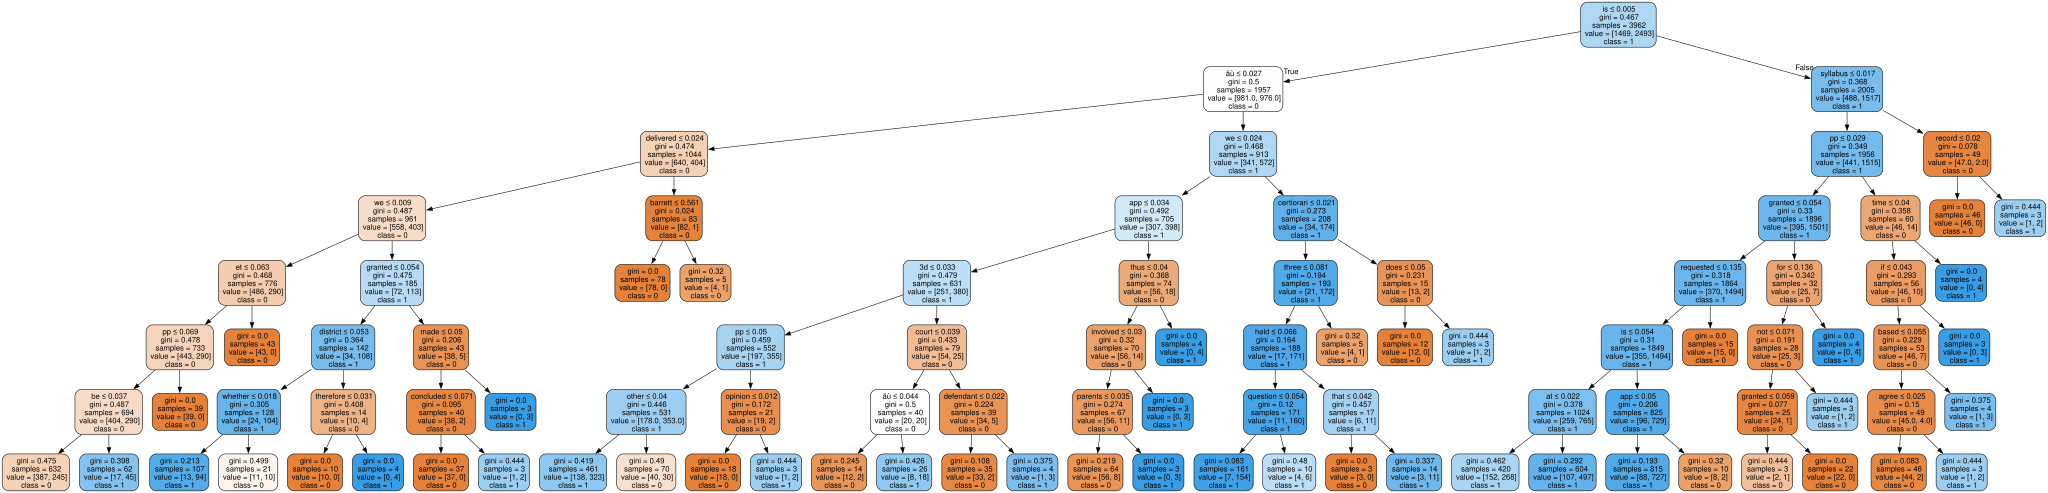

In [129]:
# visualization
from sklearn import tree
import graphviz
dot_data = tree.export_graphviz(dt_clf, out_file=None,
                                feature_names=feature_names,
                                class_names=[str(c) for c in dt_clf.classes_],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

Notice how the deicision gain here is not very encouraging from the first node split (0.005).

In [133]:
# visualization
from sklearn import tree
import graphviz
first_tree = rf_clf.estimators_[0]
dot_data = tree.export_graphviz(first_tree, out_file=None,
                                feature_names=feature_names,
                                class_names=[str(c) for c in rf_clf.classes_],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

Random Forest is marginally better at the first split (0.144) but still not great. Taking a look at the confusion matrix may help show what is happening

In [135]:
# Predict on the test set
y_pred = rf_clf.predict(X_test)

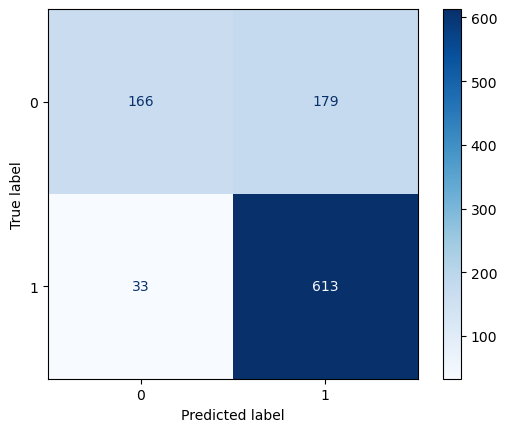

In [136]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot(cmap='Blues')

In [137]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.48      0.61       345
           1       0.77      0.95      0.85       646

    accuracy                           0.79       991
   macro avg       0.80      0.72      0.73       991
weighted avg       0.79      0.79      0.77       991



Based on these evaluations, we have some sense of where the random forest model is going wrong. The model has an overall 79% accuracy rate for predicting legal and non-legal categories. Precision for non-legal paragraphs is 83% which is the accuracy of predicting non-legal paragraphs correctly, compared to 77% for predicting legal paragraphs correctly. This suggests it is slightly harder to identify the legal paragraphs correctly. Recall is very revealing. While 95% of true legal reasoning classifications were distinguished from false negatives, only 48% of non-legal reasoning classifications were correctly distinguished. This suggests that model struggled to predict the non-legal reasoning category more so than the legal reasoning category. My suspicion is that this is due to the support imbalance since we would expect the model to make about two-thirds of classifications as legal reasoning. Thus, we should expect the recall to be much higher for legal reasoning than non-legal reasoning, which is the case here. F1 is also informative due to the imbalance between classes since it offers a balanced approach between precision and recall. It affirms that the best RF model does a better job with the legal reasoning classification task than non-legal reasoning, even though there is imbalance in the classes.

Finally, I plotted a ROC-AUC curve to consider performance across difference class probability thresholds

In [75]:
from sklearn.metrics import roc_curve, roc_auc_score

In [76]:
# generate a list of y_score as probability of being positive
y_score = rf_clf.predict_proba(X_test)[:, 1]
y_score

array([8.15055952e-01, 5.94981746e-01, 5.80032143e-01, 7.02949567e-01,
       5.29900397e-01, 6.86654437e-01, 8.04546104e-01, 8.75313347e-01,
       9.01704746e-01, 0.00000000e+00, 5.74611508e-01, 6.59034024e-01,
       3.42050144e-01, 7.43315742e-01, 7.53171032e-01, 5.62465476e-01,
       8.25648016e-01, 7.29055952e-01, 6.33317605e-01, 5.81350794e-01,
       6.29467607e-01, 7.84989286e-01, 5.65722222e-01, 6.76436652e-01,
       5.19069444e-01, 6.95416739e-01, 6.94233730e-01, 7.01267460e-01,
       6.94110317e-01, 7.64278102e-01, 7.32696825e-01, 8.64650938e-01,
       9.20687302e-01, 2.57643318e-01, 7.31569736e-01, 7.73229762e-01,
       8.80539286e-01, 3.72050168e-01, 7.12247619e-01, 7.42319264e-01,
       8.18537302e-01, 7.00458730e-01, 8.15298810e-01, 8.50684921e-01,
       7.52193536e-01, 7.80660253e-01, 8.41713889e-01, 7.61843687e-01,
       6.32216330e-01, 8.04125794e-01, 7.15267857e-01, 6.91082540e-01,
       5.47371429e-01, 6.68382937e-01, 8.73832143e-01, 8.63807504e-01,
      

In [77]:
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=1)

In [78]:
roc_score = roc_auc_score(y_test, y_score)
roc_score # this score is the area under the curve. Want it to be greater than 0.5 (greater than random)

0.8804437564499484

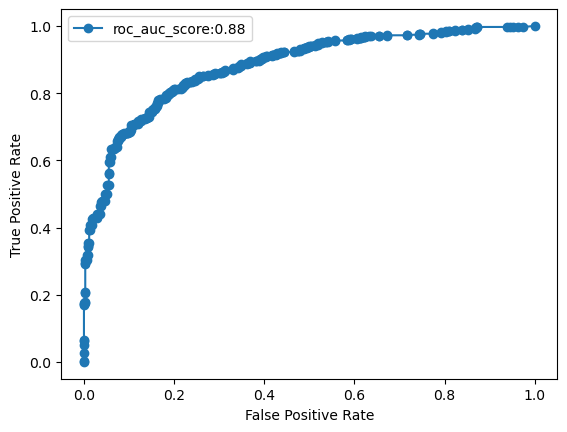

In [79]:
import matplotlib.pyplot as plt
plt.plot(fpr,tpr,'o-',label="roc_auc_score:"+str(round(roc_score, 2)))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

Overall, I think the model is performing well here, especially when compared to the DT Classifier. The ROC-AUC score of 0.88 is encouraging since it suggests there is an 88% chance the model assigns a higher probability to a randomly selected legal paragraph rather a non-legal paragraph. Still, this only represents predicted probabilities for my model's classification task. And the summary of other evaluation measures places the model in the lower 80s across various performance metrics. And the very low recall for non-legal reasoning is somewhat worrisome.

The results are encouraging, but in this setting, I expected performance to be above 90% since the task for a human coder is relatively straightforward. I next turn to a logistic regression model to see how it performs in comparison.

### Linear Model for Binary Text Classification

Start again with vectorized training data

In [48]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer(stop_words='english', max_df=0.8, min_df=5)
X_train_vec = count_vect.fit_transform(labeled_df["paragraph_text"])

print(X_train_vec.shape)

(4953, 7739)


In [49]:
# the vocabulary learned from this corpus
# word: index
count_vect.vocabulary_

{'justice': 4209,
 'gorsuch': 3590,
 'delivered': 2630,
 'opinion': 4940,
 'court': 2429,
 'thousands': 6641,
 'federal': 3329,
 'civilian': 2005,
 'employees': 2996,
 'serve': 6133,
 'nation': 4742,
 'military': 4622,
 'reservists': 5843,
 'calls': 1828,
 'active': 1135,
 'duty': 2919,
 'pays': 5090,
 'seeking': 6089,
 'address': 1155,
 'gap': 3538,
 'congress': 2244,
 'years': 7154,
 'ago': 1251,
 'adopted': 1198,
 'pay': 5085,
 'äù': 7441,
 'statute': 6344,
 'law': 4296,
 'requires': 5827,
 'government': 3598,
 'make': 4471,
 'difference': 2732,
 'employee': 2995,
 'various': 6938,
 'circumstances': 1989,
 'including': 3914,
 'called': 1826,
 'äúduring': 7534,
 'national': 4743,
 'emergency': 2983,
 'question': 5553,
 'face': 3263,
 'concerns': 2196,
 'meaning': 4553,
 'quoted': 5568,
 'language': 4286,
 'does': 2864,
 'guarantee': 3636,
 'reservist': 5842,
 'differential': 2735,
 'serves': 6135,
 'ongoing': 4925,
 'require': 5823,
 'prove': 5480,
 'service': 6136,
 'bears': 1641,
 

In [50]:
# features ordered by index
features = count_vect.get_feature_names_out()
features[100:150]

array(['150', '151', '1514a', '152', '153', '154', '1541', '155', '156',
       '157', '158', '159', '16', '160', '1600s', '161', '162', '163',
       '164', '165', '166', '167', '168', '1686', '1688', '169', '16th',
       '17', '170', '1700s', '171', '171a', '172', '173', '174', '175',
       '176', '1769', '177', '178', '1787', '1789', '179', '1791', '1794',
       '1795', '18', '180', '1803', '181'], dtype=object)

Putting this model together involved some strategic choices informed by the previous analysis with tree-based models. First, I used the the CountVectorizer instead of TFIDF since it seemed like weighting by frequency in the document may not make as much sense when working with paragraphs rather than composite documents. Second, I made sure to include in the logistic regression the `balanced` option for class_weights so that the imbalance in labels that created problems with the tree-based models might be corrected.

In [51]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    labeled_df["paragraph_text"], labeled_df["legal"], test_size=0.2, random_state=42
)

# Vectorize
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer(stop_words='english', max_df=0.8, min_df=5)
X_train_vec = count_vect.fit_transform(X_train_text)
X_test_vec = count_vect.transform(X_test_text)
X_test_vec.shape

(991, 6791)

In [52]:
# Train logistic regression
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=42)
clf.fit(X_train_vec, y_train)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
}

# run gridsearch
grid_search = GridSearchCV(
    estimator = clf,
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)
grid_search.fit(X_train, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [63]:
# best parameters
clf = LogisticRegression(random_state=42, C=10, class_weight='balanced')
clf.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
# Predict & evaluate
y_pred = clf.predict(X_test_vec)
y_pred

array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,

Now we can evaluate the model's performance and reconstruct the linear equation for the logistic regression. Based on the metrics below, it seems to have some improvements over the tree-based models. This could be due to using CountVectorizer, better weighting, or just the fact that the underlying distribution of true classifications is better approximated by a sigmoid function like logistic regression uses.

In [65]:
clf.coef_

array([[-0.53276653, -0.67120981, -0.34438054, ..., -0.02499381,
         0.47313347, -1.210023  ]], shape=(1, 6791))

In [66]:
clf.intercept_

array([-0.05714875])

In [67]:
clf.score(X_test_vec, y_test)

0.7951564076690212

In [68]:
scores = cross_val_score(clf, X_test_vec, y_test, cv=5)  # Logistic Regression
print("CV mean:", np.mean(scores))
print("CV std:", np.std(scores))

CV mean: 0.7669052332368915
CV std: 0.021002661815320085


In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       345
           1       0.85      0.83      0.84       646

    accuracy                           0.80       991
   macro avg       0.77      0.78      0.78       991
weighted avg       0.80      0.80      0.80       991



The above classification report allows us to compare the logistic regression's performance to the random forest model. The accuracy of both models is essentially the same (logistic performs just one percentage point better). But the real diffference is looking at the improvement in recall and f1 for the non-legal classification. Here, the logistic regression model performs much better than the random forest model. All other measures are quite similar, so the logistic regression model may be the better choice given its overall robust results.

I finish my evaluation by looking at the ROC-AUC curve for the logistic regression.

In [71]:
# generate a list of y_score as probability of being positive
y_score = clf.predict_proba(X_test_vec)[:, 1]
y_score

array([9.99999985e-01, 7.93869357e-01, 9.50715628e-04, 6.06840926e-01,
       1.01153174e-03, 4.27498053e-02, 9.69308281e-01, 4.06280762e-01,
       9.79272437e-01, 4.91718355e-03, 1.38006446e-02, 9.23441982e-01,
       9.08116730e-06, 8.23852742e-01, 5.32538132e-01, 5.72636419e-03,
       9.99998041e-01, 9.15610622e-01, 9.99187497e-01, 5.26958345e-03,
       9.36549283e-03, 9.99896669e-01, 1.80778695e-01, 9.99974218e-01,
       2.67525477e-02, 9.08663387e-04, 2.33731972e-02, 4.00014607e-05,
       6.04301385e-01, 5.38188349e-01, 9.99999997e-01, 9.99968573e-01,
       9.99999822e-01, 1.02301693e-01, 9.64924798e-01, 9.99999988e-01,
       9.99860460e-01, 9.83932201e-01, 7.47144531e-01, 8.43421632e-01,
       9.99334020e-01, 1.52834925e-01, 9.99995495e-01, 9.85244112e-01,
       9.99761155e-01, 9.98489842e-01, 9.99765797e-01, 9.92844978e-01,
       9.05068410e-01, 8.96427192e-01, 9.87088654e-01, 3.90627805e-02,
       8.61112919e-01, 9.24852686e-03, 9.99992912e-01, 9.99999999e-01,
      

In [72]:
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=1)

In [73]:
roc_score = roc_auc_score(y_test, y_score)
roc_score # this score is the area under the curve. Want it to be greater than 0.5 (greater than random)

0.8674025216493921

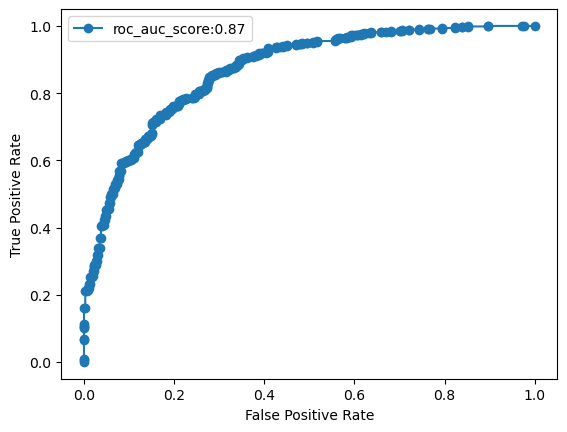

In [74]:
import matplotlib.pyplot as plt
plt.plot(fpr,tpr,'o-',label="roc_auc_score:"+str(round(roc_score, 2)))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

Like the RF model, the ROC-AUC score of the logistic regression is similar. There is an 87% chance the model assigns a higher probability to a randomly selected legal paragraph rather a non-legal paragraph. As mentioned above, given that the logistic regression model performs much better on recall than RF and then comparable across other metrics, I feel more confident using logistic regression over the tree-based models.

To supplement the quantitative evaluation metrics above, the following allows for qualitative evaluation of the LR model by looking at top predicted features based on importance

In [318]:
# top predicted features for legal portion
topn=20
for f_id in np.argsort(clf.coef_[0])[::-1][:topn]:
    print("%.3f: %s" % (clf.coef_[0][f_id], features[f_id]))

1.829: litigant
1.268: authorizing
1.120: likelihood
1.116: davila
1.094: missing
1.003: aliens
0.985: slaughtering
0.960: 203
0.946: diagnosed
0.920: admission
0.911: bodily
0.908: alike
0.901: chevron
0.896: munanka
0.892: commanded
0.892: nature
0.875: discussing
0.870: held
0.865: 196
0.856: contradicts


In [319]:
# top predicted features for non-legal portion
for f_id in np.argsort(clf.coef_[0])[::1][:topn]:
    print("%.3f: %s" % (clf.coef_[0][f_id], features[f_id]))

-3.856: modified
-2.790: repealed
-2.126: contradiction
-1.184: trait
-1.170: bock
-1.168: conduit
-1.151: employ
-1.122: accurate
-1.111: active
-1.050: discrete
-1.048: ban
-1.004: relatively
-0.966: premise
-0.937: bids
-0.899: submitted
-0.892: trillion
-0.851: determined
-0.846: municipal
-0.842: probably
-0.838: lie


I was not expecting there to be much rhyme or reason to the non-legal portions of the opinion since they typically include facts from the case and each case is so different from others. The legal portion is somewhat suggestive of what might be in the legal reasoning portion. For example, words that are used in making arguments such as `authorizing` `litigant` `alike` and `commanded` seem to fit well. There are also some outliers that would be worth exploring such as `davila` `203` and `chevron`. I got some AI assistance to write code for exploring these words.

In [320]:
word = "davila"  # example top feature
examples = labeled_df[labeled_df["paragraph_text"].str.contains(rf"\b{word}\b", case=False)]

# Show the paragraph and its label
print(examples[["paragraph_text", "legal"]].head(30))


                                         paragraph_text  legal
3103  Petitioners are basically seeking relief from ...      1
3462  This case concerns Rule 11 of the Federal Rule...      0
3463  The question presented is whether, as the Cour...      0
3464  In May 2009, a federal grand jury in the South...      0
3465  In January 2010, Davila sent a letter to the D...      0
3466  Addressing Davila‚Äôs complaint that his attor...      0
3468  As to Davila‚Äôs objection that his attorney h...      0
3469  The only thing at your disposal that is entire...      0
3470  Davila‚Äôs Sentencing Guidelines range, the Ma...      0
3471  ‚Äú[T]hat twoor three-level reduction for acce...      0
3472  Nearly a month after the in camera hearing, Da...      0
3473  In May 2010, more than three months after the ...      0
3474  Before he was sentenced, Davila moved to vacat...      0
3475  The District Judge denied Davila‚Äôs motion. I...      0
3476  On appeal, Davila‚Äôs court-appointed attorney...

In [321]:
print(labeled_df["paragraph_text"].iloc[3103])

Petitioners are basically seeking relief from what they believe are meritless, economically burdensome lawsuits. We agree that Congress sought to encourage the creation of ESOPs. And we have recognized that ‚ÄúERISA represents a ‚Äò ‚Äúcareful balancing‚Äù between ensuring fair and prompt enforcement of rights under a plan and the encouragement of the creation of such plans.‚Äô ‚Äù Conkright v. Frommert, 559 U. S. 506, 517 (2010) (quoting Aetna Health Inc. v. Davila, 542 U. S. 200, 215 (2004)); see also Varity Corp. v. Howe, 516 U. S. 489, 497 (1996) (In ‚ÄúinterOpinion of the Court pret[ing] ERISA‚Äôs fiduciary duties,‚Äù ‚Äúcourts may have to take account of competing congressional purposes, such as Congress‚Äô desire to offer employees enhanced protection for their benefits, on the one hand, and, on the other, its desire not to create a system that is so complex that administrative costs, or litigation expenses, unduly discourage employers from offering welfare benefit plans in the 

In [322]:
word = "203"  # example top feature
examples = labeled_df[labeled_df["paragraph_text"].str.contains(rf"\b{word}\b", case=False)]

# Show the paragraph and its label
print(examples[["paragraph_text", "legal"]].head(30))

                                         paragraph_text  legal
80    Notwithstanding Grupo Mexicano, the principal ...      1
248   ‚ÄúThe clearest command of the Establishment C...      1
654   The close relationship between the causes of a...      1
1981  The 2005 Action concluded in two phases. First...      0
2001  Not only that, but the complained-of conduct i...      1
2014  Opinion of the Court Congress‚Äô purpose as re...      0
2240  Federal courts have authority under the Consti...      1
2818  The then-Register of Copyrights, Abraham Kamin...      1
3286  In December 2004, Hoeper flew from Denver to V...      0
3289  I‚Äôm sorry. You are railroading the situation...      0
3324  Finally, we consider Air Wisconsin‚Äôs stateme...      1
3627  Although ‚Äúexpress[ing] our reluctance to ado...      1
3682  Novo first contends that our interpretation of...      1
4818  Congress has broad power to set the terms on w...      1


In [323]:
print(labeled_df["paragraph_text"].iloc[80])

Notwithstanding Grupo Mexicano, the principal dissent invokes Ex parte Young, 209 U. S. 123 (1908), as support for the proposition that equity can encompass remedies that have ‚Äúno analogue in the relief exercised in the English Court of Chancery,‚Äù because Ex parte Young permits plaintiffs to ‚Äúobtain plaintiff-protective injunctions against Government offcials,‚Äù and the English Court of Chancery ‚Äúcould not enjoin the Crown or English offcers,‚Äù post, at 907 (opinion of Sotomayor, J.). But contrary to the principal dissent's suggestion, Ex parte Young does not say‚Äîeither explicitly or implicitly‚Äîthat courts may devise novel remedies that have no background in traditional equitable practice. Historically, a court of equity could issue an antisuit injunction to prevent an offcer from engaging in tortious conduct. Ex parte Young justifes its holding by reference to a long line of cases authorizing suits against state offcials in certain circumstances. See 209 U. S., at 150‚Äì

In [324]:
word = "chevron"  # example top feature
examples = labeled_df[labeled_df["paragraph_text"].str.contains(rf"\b{word}\b", case=False)]

# Show the paragraph and its label
print(examples[["paragraph_text", "legal"]].head(30))

                                         paragraph_text  legal
1800  Second, the Board argues that ¬ß355(f ) should...      1
1801  The Board‚Äôs argument is unpersuasive for sev...      1
2040  Neither the Solicitor General nor any party ha...      1
2903  The disparate approach to state drug convictio...      1
3574  (c) The Court also rejects the Government‚Äôs ...      0
3598  The Government points out that the Treasury Re...      1
3600  See also Mayo Foundation for Medical Ed. and R...      1
3604  In so stating, the Court sought to encapsulate...      1
3606  apparent from the agency‚Äôs generally conferr...      1
3607  As the Government points out, the Court in Col...      1
4663  1. The phrase ‚Äúthe waters of the United Stat...      0
4729  flows intermittently or ephemerally, or channe...      1


In [325]:
print(labeled_df["paragraph_text"].iloc[1800])

Second, the Board argues that ¬ß355(f ) should be interpreted in light of ¬ß231g‚Äôs reference to decisions ‚Äúdetermining the rights or liabilities of any person.‚Äù See 45 U. S. C. ¬ß231g. The denial of reopening does not qualify for judicial review, the Board claims, because it is simply a ‚Äúrefusal to make a new determination‚Äù of rights or liabilities, like the decision this Court addressed in Your Home Visiting Nurse Services, Inc. v. Shalala, 525 U. S. 449 (1999). Id., at (emphasis deleted). In Your Home, this Court concluded that an agency intermediary‚Äôs refusal to reopen a prior Medicare reimbursement determination was not subject to further administrative review because it was not a ‚Äú ‚Äòfinal determination . . . as to the amount of total program reimbursement due.‚Äô ‚Äù Ibid. (quoting 42 U. S. C. ¬ß1395oo(a)(1)(A)(i)). The agency argued that the denial of reopening was not itself a determination ‚Äúas to the amount,‚Äù but rather a refusal to make such a determination

Taking in these snapshots, it seems like Davila and Chevron are both referring to court precedents. This makes sense since we would expect precedents to be discussed more often in the context of legal portions of the opinion than in the procedural history or non-legal background. 203 seems to just have been an anomaly in this case. 

### Error Analysis

In [112]:
train_idx, test_idx = train_test_split(np.arange(labeled_df.shape[0]), test_size=0.2,
                                       shuffle=True, random_state=42)

len(train_idx), len(test_idx)
print("Number of training examples:{}".format(len(train_idx)))
print("Number of testing examples:{}".format(len(test_idx)))

Number of training examples:3962
Number of testing examples:991


In [113]:
X_train = X_data[train_idx]
y_train = y_data[train_idx]

X_test = X_data[test_idx]
y_test = y_data[test_idx]

print("Training data: X_train : {}, y_train : {}".format(X_train.shape, y_train.shape))
print("Testing data: X_test : {}, y_test : {}".format(X_test.shape, y_test.shape))

Training data: X_train : (3962, 25356), y_train : (3962,)
Testing data: X_test : (991, 25356), y_test : (991,)


In [114]:
df_test = labeled_df.iloc[test_idx].copy()
df_test['pred_score'] = y_pred
df_test.head(3)[['paragraph_text','legal','pred_score']]

,paragraph_text,legal,pred_score
2526,"The parties here, though sharing some common g...",1,1
633,The three antifraud provisions are Section 17(...,0,1
3518,"Judged under this standard, the Court in Fox I...",0,0


In [115]:
# creating indicators for misclassified legal and non-legal paragraphs
df_test['true_legal'] = df_test['legal'] == 1
df_test['pred_legal'] = df_test['pred_score'] == 1

df_test['true_non_legal'] = df_test['legal'] == 0
df_test['pred_non_legal'] = df_test['pred_score'] == 0


df_test['misclassified_legal'] = df_test['true_legal']  & df_test['pred_non_legal']
df_test['misclassified_non_legal'] = df_test['true_non_legal']  & df_test['pred_legal']

In [117]:
df_test[df_test.misclassified_non_legal].head()[['paragraph_text','legal', 'pred_score']]

,paragraph_text,legal,pred_score
633,The three antifraud provisions are Section 17(...,0,1
1536,This Court has repeatedly recognized ‚Äúa Gove...,0,1
2561,Because Chief Justice Castille‚Äôs participati...,0,1
1694,"In April 2011, the Environmental Protection Ag...",0,1
621,"Northern Pipeline Constr. Co., 458 U. S., at 6...",0,1


In [118]:
df_test[df_test.misclassified_legal].head()[['paragraph_text','legal', 'pred_score']]

,paragraph_text,legal,pred_score
4337,"the Court Opinion of SCALIA, J.",1,0
2093,Opinion of the Court Because the appropriate ‚...,1,0
3965,The Court of Appeals‚Äô reliance on Holland v....,1,0
2339,This history teaches that Congress drafted the...,1,0
977,Opinion of the Court to invoke any other lawfu...,1,0


This function helps with the interpretability of the error analysis by highlighting how certain words are associated with each class.

In [96]:
import textwrap

# We'll use colors for convenience of viewing,
# but your implementations do not need to do this.
RED = '\033[1;31;48m'
BLUE = '\033[1;34;48m'
END = '\033[1;37;0m'

def interpretation(text, vectorizer, wrap_length=250, use_color=True):
    """
    Annotate each word feature with the learned coefficient, and color based on
    coefficient direction
    """
    # Make the annotated string
    analysis = []
    for wd in text.split():
        if wd in vectorizer.vocabulary_:
            wd_id = vectorizer.vocabulary_[wd]
            to_append = wd

            coef = clf.coef_[0, wd_id]
            
            # Red is more negative (non-legal), blue is more positive (legal)
            if use_color and coef < 0:
                to_append = RED + to_append + END
            elif use_color and coef > 0:
                to_append = BLUE + to_append + END

            to_append = to_append+'('+("%.3f" % coef)+')'


            analysis.append(to_append)
        else:
            analysis.append(wd)
    result = ' '.join(analysis)

    # Wrap the string for easier viewing
    wrapper = textwrap.TextWrapper(width=wrap_length)
    result = wrapper.fill(text=result)

    print(result)

We can start by looking at the false positives: cases where the model predicted legal reasoning even though the ground truth was non-legal reasoning.

In [123]:
interpretation(labeled_df.loc[633]['paragraph_text'], count_vect)

The three antifraud(-0.123) provisions(1.324) are Section 17(a) of the Securities Act, Section 10(b) of the Securities Exchange Act, and Section 206(0.383) of the Investment Advisers Act.
Section 17(a) prohibits(-0.115) regulated(-0.080) individuals(-0.510) from ‚Äúobtain[ing] money(-0.244) or property(-0.068) by
means(1.179) of any untrue statement(1.368) of a material(-1.207) fact,‚Äù as well as causing(-0.429) certain(-0.486) omissions(-0.027)
of material(-1.207) fact. 15(0.568) U. S. C. ¬ß77q(a)(2). As implemented(0.570) by Rule 10b‚Äì5, Section 10(b) prohibits(-0.115) using(-0.118) ‚Äúany
device, scheme, or artifice to defraud,‚Äù making(0.244) ‚Äúuntrue statement[s] of . . . material(-1.207) fact,‚Äù causing(-0.429) certain(-0.486)
material(-1.207) omissions, and ‚Äúengag[ing] in any act(-0.546) . . . which operates(-0.458) or would operate(0.400) as a fraud.‚Äù 17(-0.189) CFR
¬ß240.10b‚Äì5 (2023); see 15(0.568) U. S. C. ¬ß78j(b). And finally, Section 206(b), as implemented(0.570

The misclassification above looks more random than systematic. This paragraph is particularly rich with both legal and non-legal associated phrases. It just so happened that enough legally-associated words were part of this case background that it got classified as legal even though it was correctly classified as non-legal

In [138]:
interpretation(labeled_df.loc[621]['paragraph_text'], count_vect)

Northern Pipeline Constr. Co., 458(0.867) U. S., at 69(-0.026) n. 23(-0.483) (plurality opinion).


In contrast to the first example, this misclassification is not random. Instead, it comes from a cleaning error. This citation got picked up as its own paragraph rather than as a part of a different paragraph. The paragraph cleaning code probably missed something about the format here, so that is something that could be fixed on the front end.

Now I turn to looking at false negatives: paragraphs classified as legal but should have been classified as non-legal

In [125]:
interpretation(labeled_df.loc[2339]['paragraph_text'], count_vect)

This history(-0.062) teaches that Congress drafted(-0.771) the ATS ‚Äúto furnish jurisdiction(1.349) for a relatively(-0.392) modest(0.117)
set(-0.569) of actions(-0.949) alleging(-0.260) violations(-0.325) of the law(0.763) of nations.‚Äù Id., at 720. The principal(0.512)
objective(-0.626) of the statute, when first enacted, was to avoid(0.074) foreign(-0.056) entanglements by ensuring(0.125) the availability(0.300) of a
federal(-0.487) forum(1.560) where the failure(-0.162) to provide(0.147) one might cause(-1.845) another nation(-0.136) to
hold(-1.216) the United States Opinion of the Court responsible(0.011) for an injury(0.577) to a foreign(-0.056) citizen. See id., at 715‚Äì719; Kiobel,
569(1.007) U. S., at 123‚Äì124.


This example shows another close call. There is no single word that is tipping the balance here and most of the words seem to be correctly classified. The one that does give pause (as above) is the number `569` which is probably a result of failing to clean the paragraphs like number 621 above that contained citations.

In [121]:
interpretation(labeled_df.loc[2093]['paragraph_text'], count_vect)

Opinion of the Court Because the appropriate(-0.482) ‚Äúproceeding‚Äù in this case(0.515) is the adjudication(0.796) of the motion(-0.592) for
relief(0.899) from the automatic(-0.115) stay, the Bankruptcy Court‚Äôs order(0.554) conclusively(0.879) denying(-0.084) that
motion(-0.592) is ‚Äúfinal.‚Äù The court‚Äôs order(0.554) ended(-1.206) the stayrelief adjudication(0.796) and left(0.146) nothing more for the Bankruptcy
Court to do in that proceeding.4 The Court of Appeals therefore correctly(0.105) ranked the order(0.554) as final(0.474) and immediately(0.461) appealable, and
correctly(0.105) affirmed(-0.367) the District Court‚Äôs dismissal(-0.317) of Ritzen‚Äôs appeal(-1.184) as untimely. * * *


This example highlights how some seemingly non-legal words can have a double meaning. Words like `motion` and `appeal`are being used in a legal sense here but they also have a non-legal meaning. This can make it challenging for a logistic regression model to correctly classify and may suggest the need for capturing more semantic meaning by using a context language model like Legal-BERT.

A peek at the word `motion` across different paragraphs somewhat assuages this concern though. It looks like the logistic regression still does well at classifying this legally semantic phrase; in only 9 out of 41 instances is there a misclassification. Of course, I would expect Legal-BERT to probably do better so it is likely worth it to try.

In [128]:
df_test[df_test['paragraph_text'].str.lower().str.contains('motion', na=False)][['paragraph_text', 'legal', 'pred_score']]

,paragraph_text,legal,pred_score
2093,Opinion of the Court Because the appropriate ‚...,1,0
3058,We need not discuss this analysis at length be...,1,1
3543,"First, the Sixth Circuit held that the Kentuck...",1,1
561,"Some interlocutory district-court rulings, how...",1,1
144,"In other words, Rule 59(e) motions are ‚Äúatte...",1,1
4240,"On January 23, 2003, six months after the arti...",0,0
553,If the plaintiff's claims survive summary judg...,0,0
149,(per curiam) (affirming denial of a Rule 60(b)...,1,0
2447,"At an evidentiary hearing on Lee‚Äôs motion, b...",0,0
724,"About 15 years later, Mendez-Col√≠n moved to r...",0,0


## Conclusion

Overall, this validation test was very useful. I uncovered what I think to be a better approach to classification through a logistic regression model rather than a decision tree. I also discovered that my paragraph cleaning needs to be refined to better capture true paragraphs rather than citations since judicial opinions often contain both citations and footnotes (though more rare). I also learned how a context language model like Legal-BERT could be potentially more useful for improving my classification since it can pick up on semantic meaning of words that come from a legal context. My next steps are as follows:

- Review API output more closely and consider whether different formats of opinions are available. The current format is slip opinions which make it more challenging to isolate paragraphs with footnotes.
- Instead of CountVectorizer, try using Legal-BERT for contextual word embeddings. Compare to Logistic Regression results.
- If classification metrics still fall below 90% on the ROC-AUC score, consider some ensemble learning to improve model performance
- Once satisfied with model performance, expand the training sample and apply model to unseen test data
- Now separate the legal reasoning data for non-legal reasoning data. Label the legal reasoning data as law declaring or law applying and repeat process above for classification!